# Customer Segmentation using Unsupervised Learning

In [52]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

from IPython.display import display

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.cluster import (
    KMeans,
    AgglomerativeClustering,
    DBSCAN,
    MiniBatchKMeans
)

from sklearn.mixture import GaussianMixture

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

from scipy.stats import zscore

import joblib

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

In [2]:
# Load Dataset
df = pd.read_csv("Dataset for Data Analytics - Sheet1.csv")
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [3]:
## Dataset Shape
rows, cols = df.shape

print(f"Rows    : {rows}")
print(f"Columns : {cols}")

Rows    : 1200
Columns : 14


In [4]:
## Column Names
column_df = pd.DataFrame({

    "Column Number": range(1, len(df.columns)+1),

    "Column Name": df.columns

})

display(column_df)

,Column Number,Column Name
0,1,OrderID
1,2,Date
2,3,CustomerID
3,4,Product
4,5,Quantity
5,6,UnitPrice
6,7,ShippingAddress
7,8,PaymentMethod
8,9,OrderStatus
9,10,TrackingNumber


In [5]:
## Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          1200 non-null   object 
 1   Date             1200 non-null   object 
 2   CustomerID       1200 non-null   object 
 3   Product          1200 non-null   object 
 4   Quantity         1200 non-null   int64  
 5   UnitPrice        1200 non-null   float64
 6   ShippingAddress  1200 non-null   object 
 7   PaymentMethod    1200 non-null   object 
 8   OrderStatus      1200 non-null   object 
 9   TrackingNumber   1200 non-null   object 
 10  ItemsInCart      1200 non-null   int64  
 11  CouponCode       891 non-null    object 
 12  ReferralSource   1200 non-null   object 
 13  TotalPrice       1200 non-null   float64
dtypes: float64(2), int64(2), object(10)
memory usage: 131.4+ KB


In [6]:
## Data Types
dtype_df = pd.DataFrame({

    "Feature": df.columns,

    "Data Type": df.dtypes.values

})

display(dtype_df)

,Feature,Data Type
0,OrderID,object
1,Date,object
2,CustomerID,object
3,Product,object
4,Quantity,int64
5,UnitPrice,float64
6,ShippingAddress,object
7,PaymentMethod,object
8,OrderStatus,object
9,TrackingNumber,object


In [7]:
## Statistical Summary
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Quantity,1200.0,2.945833,1.407557,1.00,2.0000,3.000,4.000,5.00
UnitPrice,1200.0,356.412750,197.177146,11.39,186.0625,364.210,521.570,699.93
ItemsInCart,1200.0,5.485000,2.281983,1.00,4.0000,5.000,7.000,10.00
TotalPrice,1200.0,1053.968300,819.856558,11.39,410.5200,823.615,1578.475,3456.40


In [8]:
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
OrderID,1200,1200,ORD201183,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date,1200,671,2023-08-20,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CustomerID,1200,1189,C38840,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product,1200,7,Printer,181,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,1200.0,NaN,NaN,NaN,2.945833,1.407557,1.0,2.0,3.0,4.0,5.0
UnitPrice,1200.0,NaN,NaN,NaN,356.41275,197.177146,11.39,186.0625,364.21,521.57,699.93
ShippingAddress,1200,655,533 Main St,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PaymentMethod,1200,5,Online,258,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OrderStatus,1200,5,Cancelled,250,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TrackingNumber,1200,1200,TRK83653396,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Missing Value Analysis

In [9]:
missing_df = pd.DataFrame({

    "Missing Values": df.isnull().sum(),

    "Percentage": round(df.isnull().mean()*100,2)

})

missing_df = missing_df.sort_values(

    by="Missing Values",

    ascending=False

)

display(missing_df)

,Missing Values,Percentage
CouponCode,309,25.75
OrderID,0,0.00
CustomerID,0,0.00
Product,0,0.00
Quantity,0,0.00
Date,0,0.00
UnitPrice,0,0.00
ShippingAddress,0,0.00
OrderStatus,0,0.00
PaymentMethod,0,0.00


In [10]:
## Duplicate Records
duplicates = df.duplicated().sum()

print(f"Duplicate Records : {duplicates}")

Duplicate Records : 0


In [11]:
## Unique Value Analysis
unique_df = pd.DataFrame({
    "Feature": df.columns,
    "Unique Values": df.nunique().values
})

display(unique_df.sort_values(by="Unique Values", ascending=False))

,Feature,Unique Values
0,OrderID,1200
9,TrackingNumber,1200
13,TotalPrice,1195
5,UnitPrice,1193
2,CustomerID,1189
1,Date,671
6,ShippingAddress,655
10,ItemsInCart,10
3,Product,7
4,Quantity,5


In [12]:
## Dataset Memory Usage
memory_usage = df.memory_usage(deep=True).sum() / (1024**2)

print(f"Dataset Memory Usage : {memory_usage:.2f} MB")

Dataset Memory Usage : 0.69 MB


In [13]:
## Numerical and Categorical Features

numerical_columns = df.select_dtypes(include=np.number).columns.tolist()

categorical_columns = df.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print(f"Numerical Features   : {len(numerical_columns)}")
print(f"Categorical Features : {len(categorical_columns)}")

print("\nNumerical Columns")
display(numerical_columns)

print("\nCategorical Columns")
display(categorical_columns)

Numerical Features   : 4
Categorical Features : 10

Numerical Columns


['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']


Categorical Columns


['OrderID',
 'Date',
 'CustomerID',
 'Product',
 'ShippingAddress',
 'PaymentMethod',
 'OrderStatus',
 'TrackingNumber',
 'CouponCode',
 'ReferralSource']

In [14]:
## Data Quality Report
quality_report = pd.DataFrame({

    "Data Type": df.dtypes,

    "Missing Values": df.isnull().sum(),

    "Missing %": round(df.isnull().mean()*100,2),

    "Unique Values": df.nunique()

})

display(quality_report)

,Data Type,Missing Values,Missing %,Unique Values
OrderID,object,0,0.00,1200
Date,object,0,0.00,671
CustomerID,object,0,0.00,1189
Product,object,0,0.00,7
Quantity,int64,0,0.00,5
UnitPrice,float64,0,0.00,1193
ShippingAddress,object,0,0.00,655
PaymentMethod,object,0,0.00,5
OrderStatus,object,0,0.00,5
TrackingNumber,object,0,0.00,1200


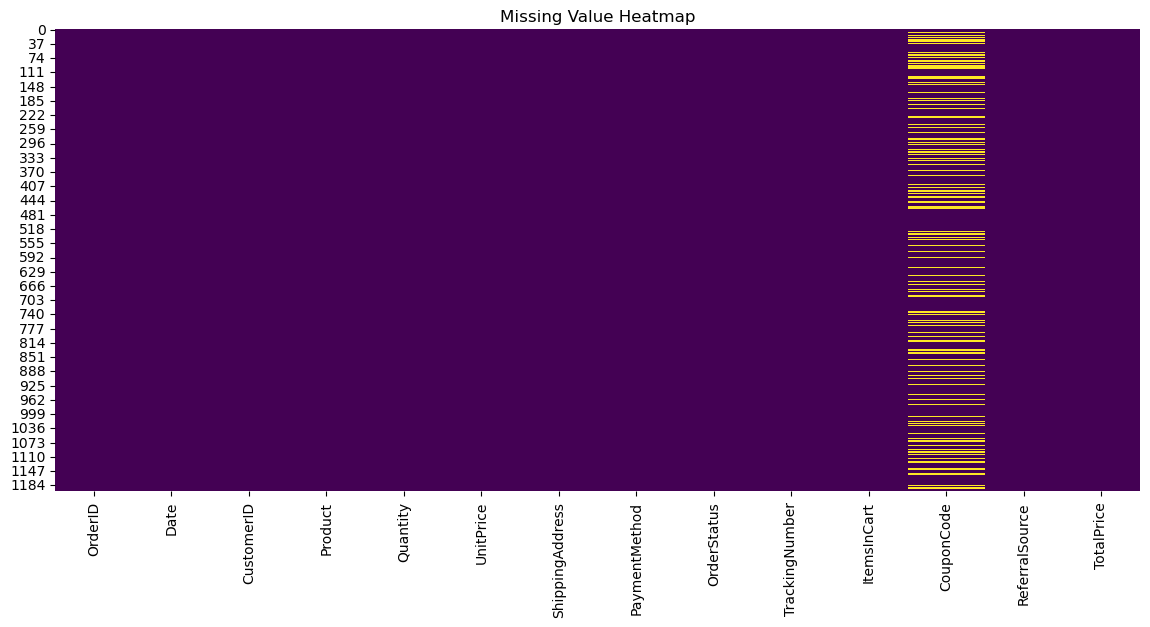

In [15]:
## Missing Value Heatmap
plt.figure(figsize=(14,6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap="viridis"
)

plt.title("Missing Value Heatmap")

plt.show()

## Data Cleaning

In [16]:
## Duplicate Record Removal
duplicate_count = df.duplicated().sum()

print(f"Duplicate Records Before : {duplicate_count}")

df.drop_duplicates(inplace=True)

duplicate_count_after = df.duplicated().sum()

print(f"Duplicate Records After  : {duplicate_count_after}")

print(f"Current Shape : {df.shape}")

Duplicate Records Before : 0
Duplicate Records After  : 0
Current Shape : (1200, 14)


In [17]:
## Missing Value Treatment
num_cols = df.select_dtypes(include=np.number).columns

cat_cols = df.select_dtypes(
    include=["object", "category"]
).columns

for col in num_cols:

    df[col].fillna(df[col].median(), inplace=True)

for col in cat_cols:

    df[col].fillna(df[col].mode()[0], inplace=True)

print("Missing Values Treated Successfully.")

Missing Values Treated Successfully.


In [18]:
df.isnull().sum()

OrderID            0
Date               0
CustomerID         0
Product            0
Quantity           0
UnitPrice          0
ShippingAddress    0
PaymentMethod      0
OrderStatus        0
TrackingNumber     0
ItemsInCart        0
CouponCode         0
ReferralSource     0
TotalPrice         0
dtype: int64

In [19]:
## Outlier Detection using IQR
outlier_summary = []

for col in numerical_columns:

    Q1 = df[col].quantile(0.25)

    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR

    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ].shape[0]

    outlier_summary.append(
        [col, outliers]
    )

outlier_df = pd.DataFrame(
    outlier_summary,
    columns=["Feature", "Outliers"]
)

display(outlier_df)

,Feature,Outliers
0,Quantity,0
1,UnitPrice,0
2,ItemsInCart,0
3,TotalPrice,8


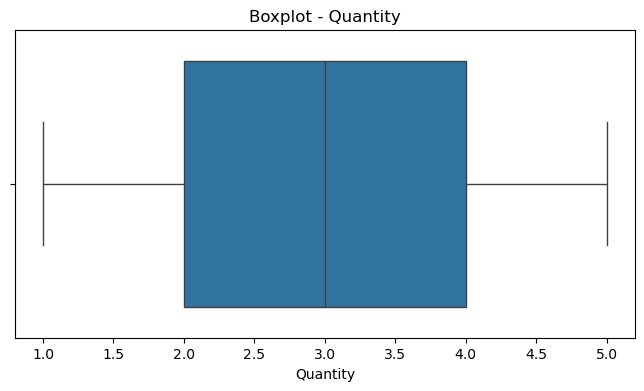

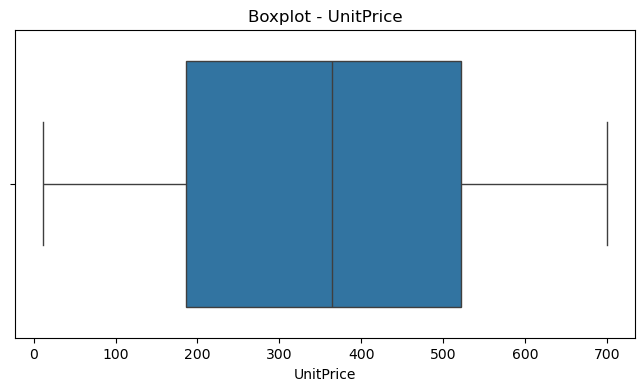

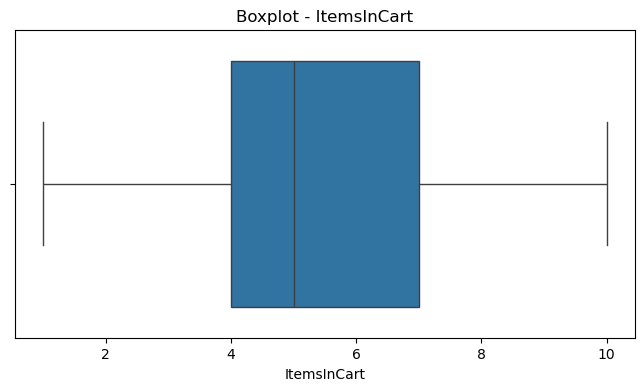

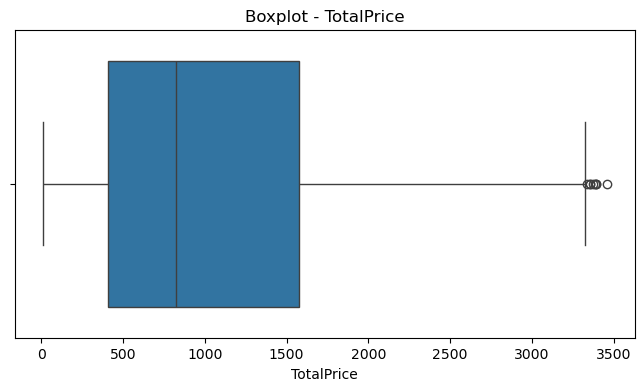

In [20]:
## Outlier Visualization
for col in numerical_columns:

    plt.figure(figsize=(8,4))

    sns.boxplot(x=df[col])

    plt.title(f"Boxplot - {col}")

    plt.show()

In [21]:
## Outlier Treatment using IQR
df_clean = df.copy()

for col in numerical_columns:

    Q1 = df_clean[col].quantile(0.25)

    Q3 = df_clean[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR

    upper = Q3 + 1.5 * IQR

    df_clean[col] = np.where(
        df_clean[col] < lower,
        lower,
        df_clean[col]
    )

    df_clean[col] = np.where(
        df_clean[col] > upper,
        upper,
        df_clean[col]
    )

df = df_clean.copy()

print("Outlier Treatment Completed.")

Outlier Treatment Completed.


In [22]:
## Data Cleaning Summary
summary = pd.DataFrame({

    "Rows": [df.shape[0]],

    "Columns": [df.shape[1]],

    "Missing Values": [df.isnull().sum().sum()],

    "Duplicate Records": [df.duplicated().sum()]

})

display(summary)

print("Data Cleaning Completed Successfully.")

,Rows,Columns,Missing Values,Duplicate Records
0,1200,14,0,0


Data Cleaning Completed Successfully.


## Exploratory Data Analysis

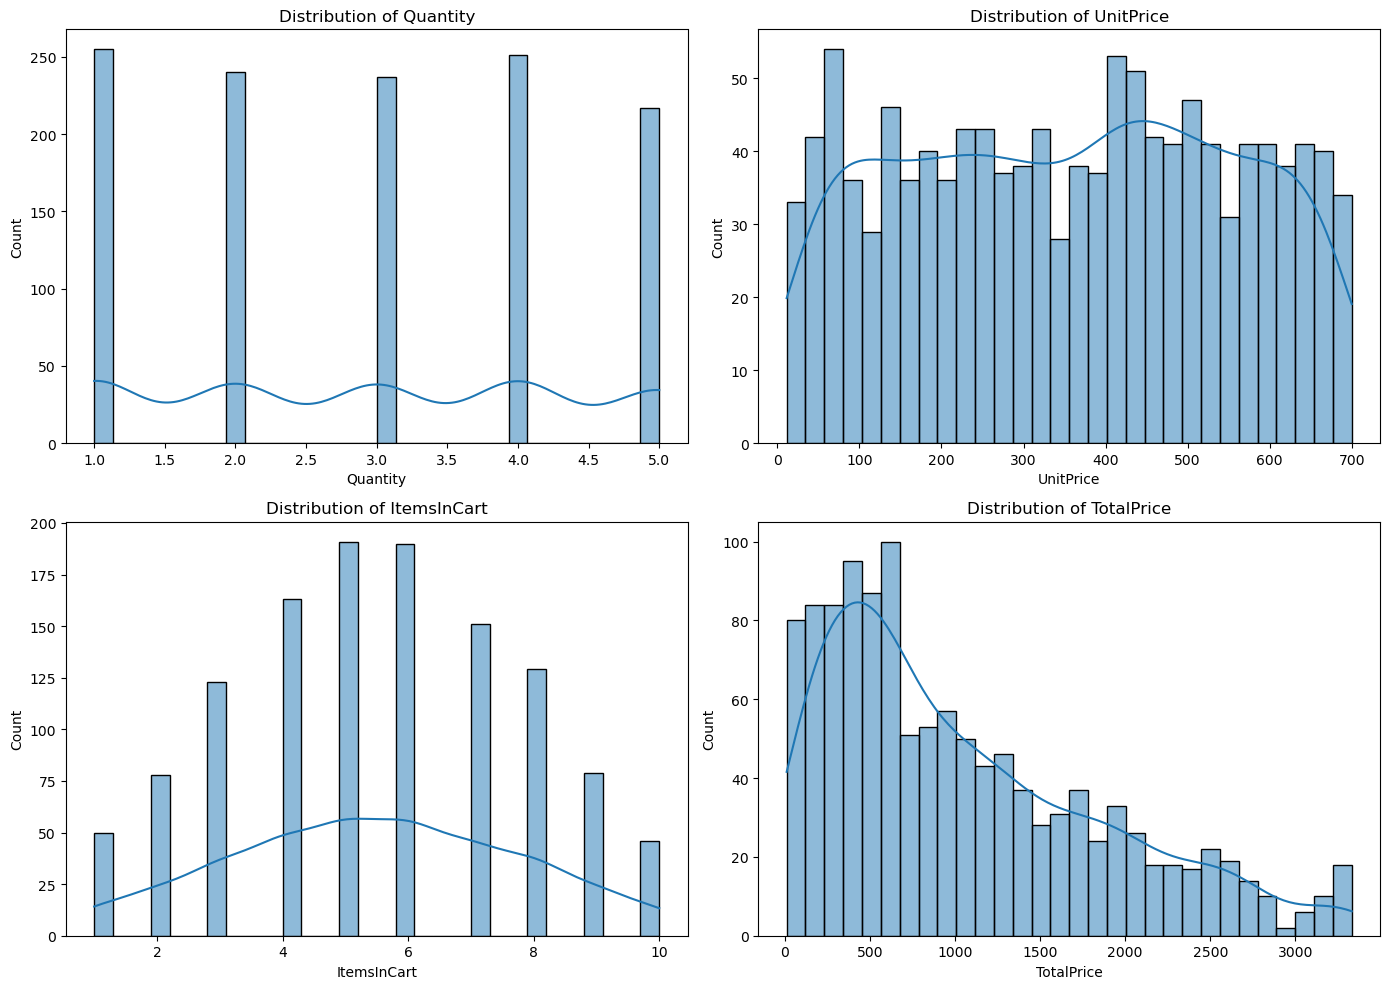

In [23]:
## Numerical Feature Distribution

numerical_features = [
    "Quantity",
    "UnitPrice",
    "ItemsInCart",
    "TotalPrice"
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col in zip(axes.flatten(), numerical_features):

    sns.histplot(
        data=df,
        x=col,
        kde=True,
        bins=30,
        ax=ax
    )

    ax.set_title(f"Distribution of {col}")

plt.tight_layout()

plt.show()

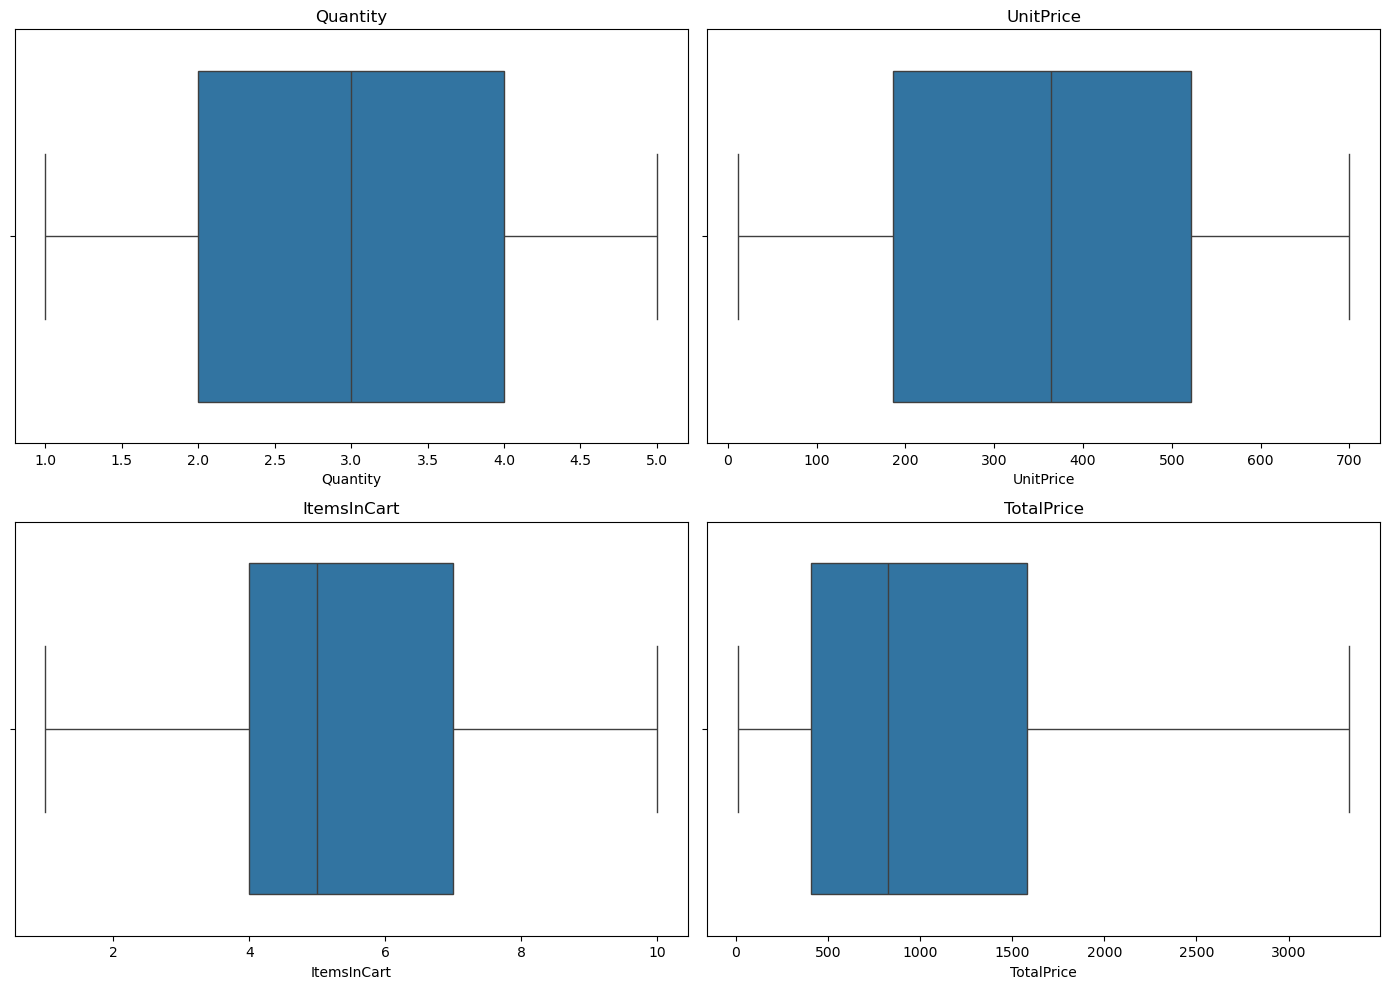

In [24]:
## Numerical Feature Boxplots
fig, axes = plt.subplots(2,2,figsize=(14,10))

for ax,col in zip(axes.flatten(),numerical_features):

    sns.boxplot(
        x=df[col],
        ax=ax
    )

    ax.set_title(col)

plt.tight_layout()

plt.show()

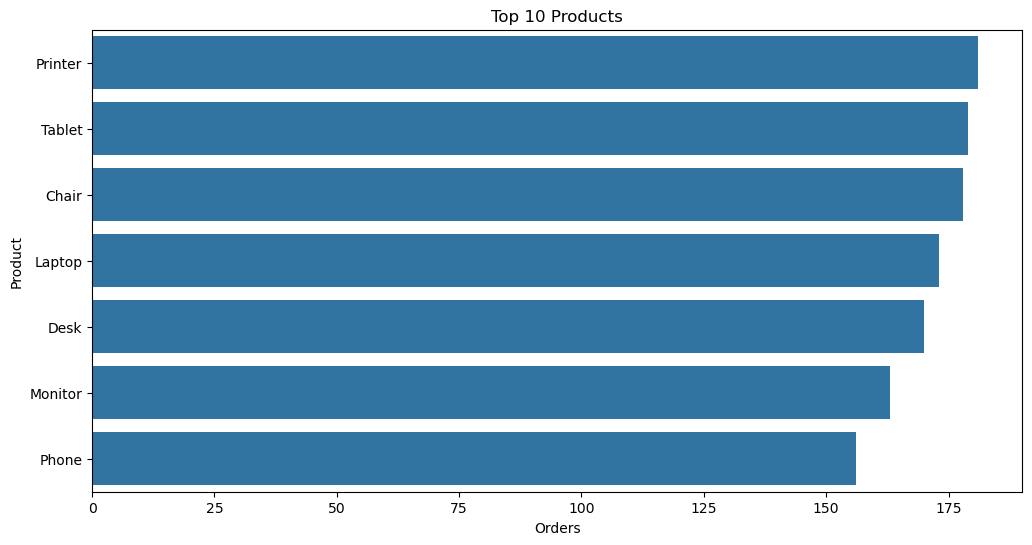

In [25]:
## Product Distribution

top_products = (
    df["Product"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title("Top 10 Products")

plt.xlabel("Orders")

plt.ylabel("Product")

plt.show()

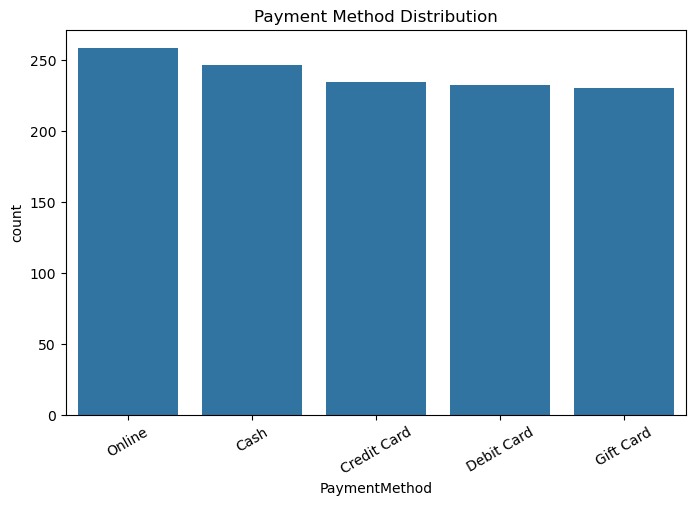

In [26]:
## Payment Method Distribution

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="PaymentMethod",
    order=df["PaymentMethod"].value_counts().index
)

plt.xticks(rotation=30)

plt.title("Payment Method Distribution")

plt.show()

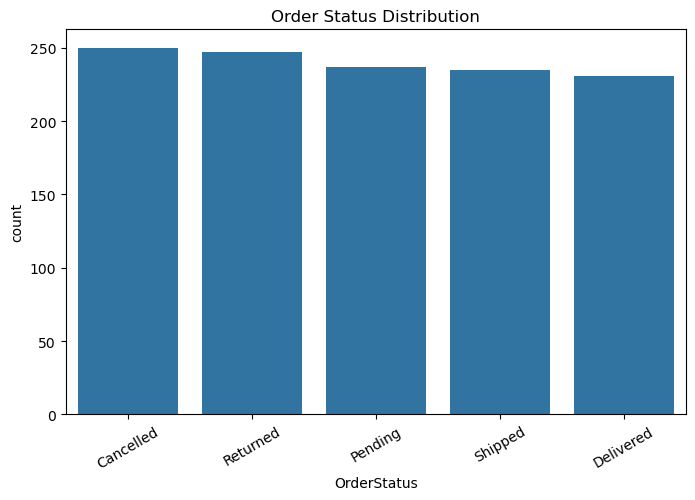

In [27]:
## Order Status Distribution
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="OrderStatus",
    order=df["OrderStatus"].value_counts().index
)

plt.xticks(rotation=30)

plt.title("Order Status Distribution")

plt.show()

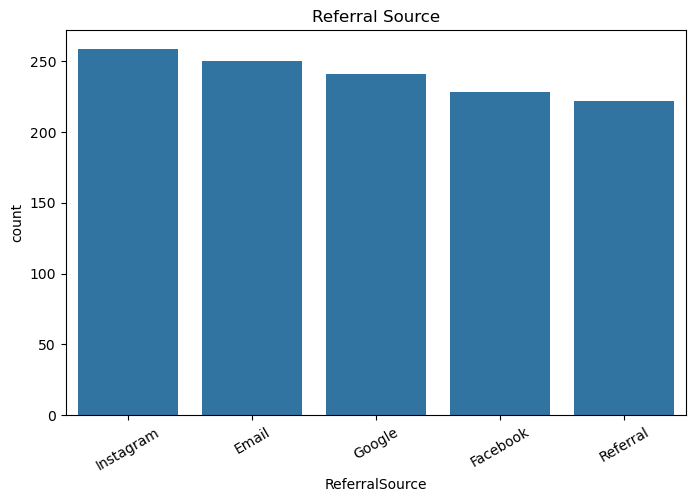

In [28]:
## Referral Source Distribution
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="ReferralSource",
    order=df["ReferralSource"].value_counts().index
)

plt.xticks(rotation=30)

plt.title("Referral Source")

plt.show()

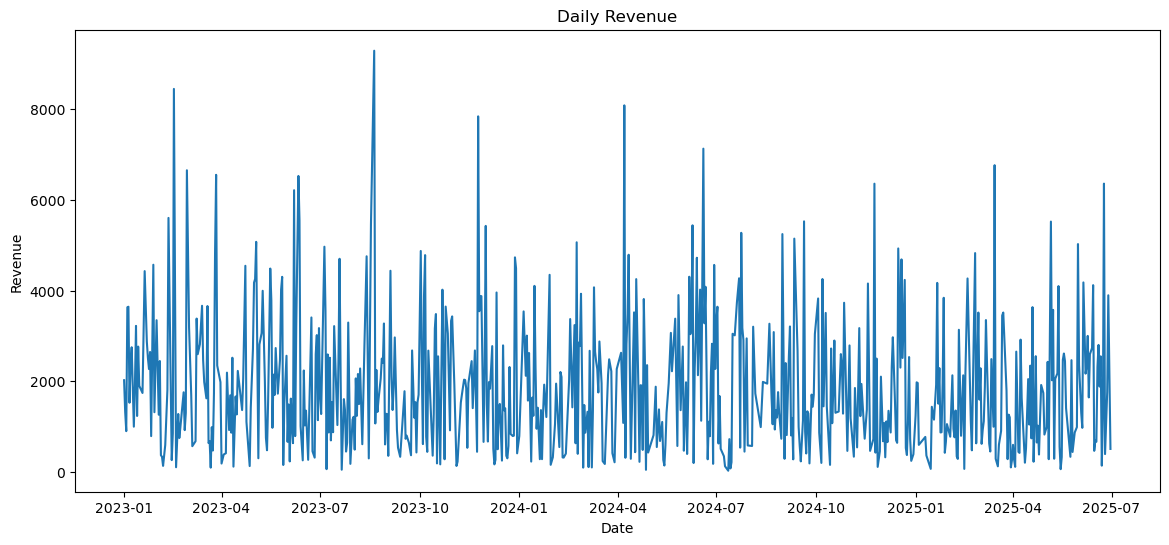

In [29]:
## Sales Trend
df["Date"] = pd.to_datetime(df["Date"])

daily_sales = (
    df.groupby("Date")["TotalPrice"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(14,6))

plt.plot(
    daily_sales["Date"],
    daily_sales["TotalPrice"]
)

plt.title("Daily Revenue")

plt.xlabel("Date")

plt.ylabel("Revenue")

plt.show()

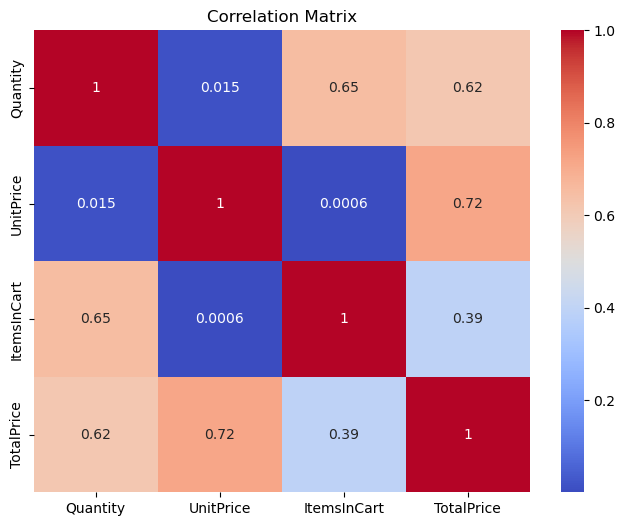

In [30]:
## Correlation Heatmap

plt.figure(figsize=(8,6))

sns.heatmap(

    df[numerical_features].corr(),

    annot=True,

    cmap="coolwarm"

)

plt.title("Correlation Matrix")

plt.show()

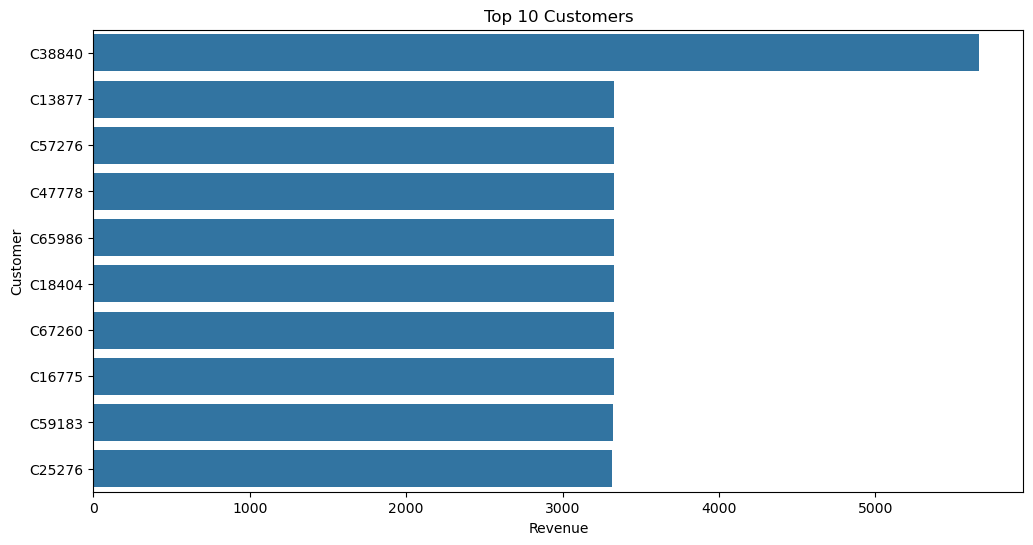

In [31]:
## Top Customers by Revenue
top_customers = (

    df.groupby("CustomerID")["TotalPrice"]

    .sum()

    .sort_values(ascending=False)

    .head(10)

)

plt.figure(figsize=(12,6))

sns.barplot(

    x=top_customers.values,

    y=top_customers.index.astype(str)

)

plt.title("Top 10 Customers")

plt.xlabel("Revenue")

plt.ylabel("Customer")

plt.show()

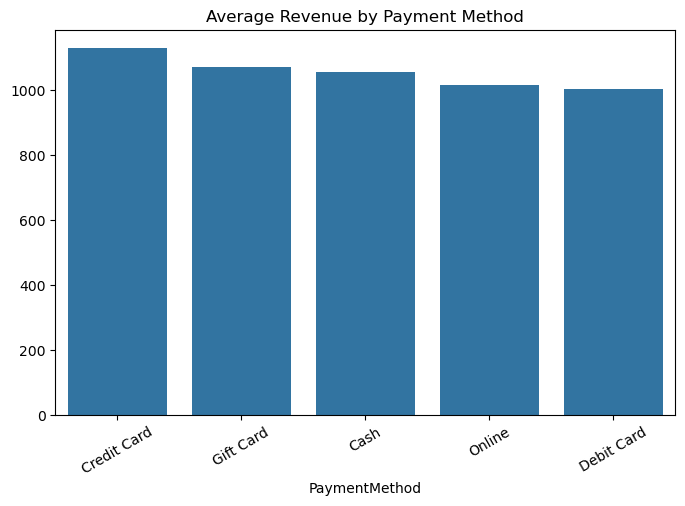

In [32]:
## Average Revenue by Payment Method
payment_sales = (

    df.groupby("PaymentMethod")["TotalPrice"]

    .mean()

    .sort_values(ascending=False)

)

plt.figure(figsize=(8,5))

sns.barplot(

    x=payment_sales.index,

    y=payment_sales.values

)

plt.xticks(rotation=30)

plt.title("Average Revenue by Payment Method")

plt.show()

In [33]:
## Interactive Revenue Analysis
fig = px.bar(

    x=top_products.index,

    y=top_products.values,

    labels={

        "x":"Product",

        "y":"Orders"

    },

    title="Top Products"

)

fig.show()

In [34]:
## EDA Summary Dashboard

summary = pd.DataFrame({

    "Metric":[

        "Total Orders",

        "Unique Customers",

        "Unique Products",

        "Average Revenue",

        "Maximum Revenue"

    ],

    "Value":[

        len(df),

        df["CustomerID"].nunique(),

        df["Product"].nunique(),

        round(df["TotalPrice"].mean(),2),

        round(df["TotalPrice"].max(),2)

    ]

})

display(summary)

,Metric,Value
0,Total Orders,1200.00
1,Unique Customers,1189.00
2,Unique Products,7.00
3,Average Revenue,1053.64
4,Maximum Revenue,3330.41


## Feature Engineering

In [35]:
## Create Customer Level Dataset

customer_df = (
    df.groupby("CustomerID")
      .agg(
          Total_Orders=("OrderID", "nunique"),
          Total_Quantity=("Quantity", "sum"),
          Total_Spending=("TotalPrice", "sum"),
          Average_Order_Value=("TotalPrice", "mean"),
          Average_Unit_Price=("UnitPrice", "mean"),
          Average_Items_In_Cart=("ItemsInCart", "mean")
      )
      .reset_index()
)

display(customer_df.head())

,CustomerID,Total_Orders,Total_Quantity,Total_Spending,Average_Order_Value,Average_Unit_Price,Average_Items_In_Cart
0,C10002,1,3.0,1470.03,1470.03,490.01,4.0
1,C10054,1,2.0,153.48,153.48,76.74,7.0
2,C10126,1,2.0,1349.80,1349.80,674.90,4.0
3,C10154,1,4.0,1303.04,1303.04,325.76,8.0
4,C10211,1,5.0,635.90,635.90,127.18,10.0


In [36]:
## Customer Purchase Timeline

purchase_dates = (
    df.groupby("CustomerID")
      .agg(
          First_Purchase=("Date","min"),
          Last_Purchase=("Date","max")
      )
      .reset_index()
)

customer_df = customer_df.merge(
    purchase_dates,
    on="CustomerID"
)

display(customer_df.head())

,CustomerID,Total_Orders,Total_Quantity,Total_Spending,Average_Order_Value,Average_Unit_Price,Average_Items_In_Cart,First_Purchase,Last_Purchase
0,C10002,1,3.0,1470.03,1470.03,490.01,4.0,2023-10-16,2023-10-16
1,C10054,1,2.0,153.48,153.48,76.74,7.0,2024-10-14,2024-10-14
2,C10126,1,2.0,1349.80,1349.80,674.90,4.0,2023-06-18,2023-06-18
3,C10154,1,4.0,1303.04,1303.04,325.76,8.0,2024-07-29,2024-07-29
4,C10211,1,5.0,635.90,635.90,127.18,10.0,2024-05-09,2024-05-09


In [37]:
## Customer Tenure

latest_date = df["Date"].max()

customer_df["Customer_Tenure"] = (
    latest_date - customer_df["First_Purchase"]
).dt.days

customer_df["Days_Since_Last_Order"] = (
    latest_date - customer_df["Last_Purchase"]
).dt.days

display(customer_df.head())

,CustomerID,Total_Orders,Total_Quantity,Total_Spending,Average_Order_Value,Average_Unit_Price,Average_Items_In_Cart,First_Purchase,Last_Purchase,Customer_Tenure,Days_Since_Last_Order
0,C10002,1,3.0,1470.03,1470.03,490.01,4.0,2023-10-16,2023-10-16,623,623
1,C10054,1,2.0,153.48,153.48,76.74,7.0,2024-10-14,2024-10-14,259,259
2,C10126,1,2.0,1349.80,1349.80,674.90,4.0,2023-06-18,2023-06-18,743,743
3,C10154,1,4.0,1303.04,1303.04,325.76,8.0,2024-07-29,2024-07-29,336,336
4,C10211,1,5.0,635.90,635.90,127.18,10.0,2024-05-09,2024-05-09,417,417


In [38]:
## Purchase Frequency
customer_df["Purchase_Frequency"] = (
    customer_df["Total_Orders"] /
    (customer_df["Customer_Tenure"] + 1)
).round(2)

display(customer_df.head())

,CustomerID,Total_Orders,Total_Quantity,Total_Spending,Average_Order_Value,Average_Unit_Price,Average_Items_In_Cart,First_Purchase,Last_Purchase,Customer_Tenure,Days_Since_Last_Order,Purchase_Frequency
0,C10002,1,3.0,1470.03,1470.03,490.01,4.0,2023-10-16,2023-10-16,623,623,0.0
1,C10054,1,2.0,153.48,153.48,76.74,7.0,2024-10-14,2024-10-14,259,259,0.0
2,C10126,1,2.0,1349.80,1349.80,674.90,4.0,2023-06-18,2023-06-18,743,743,0.0
3,C10154,1,4.0,1303.04,1303.04,325.76,8.0,2024-07-29,2024-07-29,336,336,0.0
4,C10211,1,5.0,635.90,635.90,127.18,10.0,2024-05-09,2024-05-09,417,417,0.0


In [39]:
## Favorite Product
favorite_product = (
    df.groupby("CustomerID")["Product"]
      .agg(lambda x: x.mode().iloc[0])
      .reset_index(name="Favorite_Product")
)

customer_df = customer_df.merge(
    favorite_product,
    on="CustomerID"
)

In [40]:
## Preferred Payment Method
payment = (
    df.groupby("CustomerID")["PaymentMethod"]
      .agg(lambda x: x.mode().iloc[0])
      .reset_index(name="Preferred_Payment")
)

customer_df = customer_df.merge(
    payment,
    on="CustomerID"
)

In [41]:
## Preferred Referral Source
referral = (
    df.groupby("CustomerID")["ReferralSource"]
      .agg(lambda x: x.mode().iloc[0])
      .reset_index(name="Preferred_Referral")
)

customer_df = customer_df.merge(
    referral,
    on="CustomerID"
)

display(customer_df.head())

,CustomerID,Total_Orders,Total_Quantity,Total_Spending,Average_Order_Value,Average_Unit_Price,Average_Items_In_Cart,First_Purchase,Last_Purchase,Customer_Tenure,Days_Since_Last_Order,Purchase_Frequency,Favorite_Product,Preferred_Payment,Preferred_Referral
0,C10002,1,3.0,1470.03,1470.03,490.01,4.0,2023-10-16,2023-10-16,623,623,0.0,Printer,Cash,Facebook
1,C10054,1,2.0,153.48,153.48,76.74,7.0,2024-10-14,2024-10-14,259,259,0.0,Laptop,Cash,Instagram
2,C10126,1,2.0,1349.80,1349.80,674.90,4.0,2023-06-18,2023-06-18,743,743,0.0,Monitor,Online,Facebook
3,C10154,1,4.0,1303.04,1303.04,325.76,8.0,2024-07-29,2024-07-29,336,336,0.0,Desk,Gift Card,Email
4,C10211,1,5.0,635.90,635.90,127.18,10.0,2024-05-09,2024-05-09,417,417,0.0,Desk,Debit Card,Google


In [42]:
## Customer Feature Summary
display(customer_df.describe().T)

,count,mean,min,25%,50%,75%,max,std
Total_Orders,1189.0,1.009251,1.0,1.0,1.0,1.0,2.0,0.095779
Total_Quantity,1189.0,2.973087,1.0,2.0,3.0,4.0,9.0,1.432881
Total_Spending,1189.0,1063.390934,11.39,414.47,834.12,1599.85,5662.6875,828.49836
Average_Order_Value,1189.0,1055.201179,11.39,410.91,826.4,1580.35,3330.4075,817.275488
Average_Unit_Price,1189.0,356.770063,11.39,187.97,364.14,524.06,699.93,196.816774
Average_Items_In_Cart,1189.0,5.489066,1.0,4.0,5.0,7.0,10.0,2.2743
First_Purchase,1189,2024-03-21 07:02:40.470983936,2023-01-01 00:00:00,2023-08-02 00:00:00,2024-03-18 00:00:00,2024-11-06 00:00:00,2025-06-30 00:00:00,NaN
Last_Purchase,1189,2024-03-24 17:11:51.522287872,2023-01-01 00:00:00,2023-08-07 00:00:00,2024-03-26 00:00:00,2024-11-10 00:00:00,2025-06-30 00:00:00,NaN
Customer_Tenure,1189.0,465.706476,0.0,236.0,469.0,698.0,911.0,266.241904
Days_Since_Last_Order,1189.0,462.283431,0.0,232.0,461.0,693.0,911.0,265.896491


In [43]:
## Encode Categorical Features

customer_encoded = pd.get_dummies(

    customer_df,

    columns=[
        "Favorite_Product",
        "Preferred_Payment",
        "Preferred_Referral"
    ],

    drop_first=True

)

display(customer_encoded.head())

,CustomerID,Total_Orders,Total_Quantity,Total_Spending,Average_Order_Value,Average_Unit_Price,Average_Items_In_Cart,First_Purchase,Last_Purchase,Customer_Tenure,...,Favorite_Product_Printer,Favorite_Product_Tablet,Preferred_Payment_Credit Card,Preferred_Payment_Debit Card,Preferred_Payment_Gift Card,Preferred_Payment_Online,Preferred_Referral_Facebook,Preferred_Referral_Google,Preferred_Referral_Instagram,Preferred_Referral_Referral
0,C10002,1,3.0,1470.03,1470.03,490.01,4.0,2023-10-16,2023-10-16,623,...,True,False,False,False,False,False,True,False,False,False
1,C10054,1,2.0,153.48,153.48,76.74,7.0,2024-10-14,2024-10-14,259,...,False,False,False,False,False,False,False,False,True,False
2,C10126,1,2.0,1349.80,1349.80,674.90,4.0,2023-06-18,2023-06-18,743,...,False,False,False,False,False,True,True,False,False,False
3,C10154,1,4.0,1303.04,1303.04,325.76,8.0,2024-07-29,2024-07-29,336,...,False,False,False,False,True,False,False,False,False,False
4,C10211,1,5.0,635.90,635.90,127.18,10.0,2024-05-09,2024-05-09,417,...,False,False,False,True,False,False,False,True,False,False


In [44]:
## Select Features for Clustering
features = customer_encoded.drop(

    columns=[
        "CustomerID",
        "First_Purchase",
        "Last_Purchase"
    ]

)

display(features.head())

,Total_Orders,Total_Quantity,Total_Spending,Average_Order_Value,Average_Unit_Price,Average_Items_In_Cart,Customer_Tenure,Days_Since_Last_Order,Purchase_Frequency,Favorite_Product_Desk,...,Favorite_Product_Printer,Favorite_Product_Tablet,Preferred_Payment_Credit Card,Preferred_Payment_Debit Card,Preferred_Payment_Gift Card,Preferred_Payment_Online,Preferred_Referral_Facebook,Preferred_Referral_Google,Preferred_Referral_Instagram,Preferred_Referral_Referral
0,1,3.0,1470.03,1470.03,490.01,4.0,623,623,0.0,False,...,True,False,False,False,False,False,True,False,False,False
1,1,2.0,153.48,153.48,76.74,7.0,259,259,0.0,False,...,False,False,False,False,False,False,False,False,True,False
2,1,2.0,1349.80,1349.80,674.90,4.0,743,743,0.0,False,...,False,False,False,False,False,True,True,False,False,False
3,1,4.0,1303.04,1303.04,325.76,8.0,336,336,0.0,True,...,False,False,False,False,True,False,False,False,False,False
4,1,5.0,635.90,635.90,127.18,10.0,417,417,0.0,True,...,False,False,False,True,False,False,False,True,False,False


In [45]:
## Feature Scaling
scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

scaled_df = pd.DataFrame(

    scaled_features,

    columns=features.columns

)

display(scaled_df.head())

,Total_Orders,Total_Quantity,Total_Spending,Average_Order_Value,Average_Unit_Price,Average_Items_In_Cart,Customer_Tenure,Days_Since_Last_Order,Purchase_Frequency,Favorite_Product_Desk,...,Favorite_Product_Printer,Favorite_Product_Tablet,Preferred_Payment_Credit Card,Preferred_Payment_Debit Card,Preferred_Payment_Gift Card,Preferred_Payment_Online,Preferred_Referral_Facebook,Preferred_Referral_Google,Preferred_Referral_Instagram,Preferred_Referral_Referral
0,-0.096633,0.018791,0.491021,0.507789,0.677259,-0.655012,0.591040,0.604687,-0.160715,-0.408449,...,2.367605,-0.415432,-0.495001,-0.488407,-0.487086,-0.519903,2.069890,-0.502889,-0.522512,-0.475156
1,-0.096633,-0.679398,-1.098727,-1.103790,-1.423394,0.664631,-0.776713,-0.764843,-0.160715,-0.408449,...,-0.422368,-0.415432,-0.495001,-0.488407,-0.487086,-0.519903,-0.483117,-0.502889,1.913830,-0.475156
2,-0.096633,-0.679398,0.345842,0.360616,1.617056,-0.655012,1.041948,1.056181,-0.160715,-0.408449,...,-0.422368,-0.415432,-0.495001,-0.488407,-0.487086,1.923436,2.069890,-0.502889,-0.522512,-0.475156
3,-0.096633,0.716979,0.289379,0.303378,-0.157624,1.104511,-0.487380,-0.475134,-0.160715,2.448289,...,-0.422368,-0.415432,-0.495001,-0.488407,2.053025,-0.519903,-0.483117,-0.502889,-0.522512,-0.475156
4,-0.096633,1.415168,-0.516200,-0.513263,-1.167008,1.984273,-0.183018,-0.170376,-0.160715,2.448289,...,-0.422368,-0.415432,-0.495001,2.047472,-0.487086,-0.519903,-0.483117,1.988509,-0.522512,-0.475156


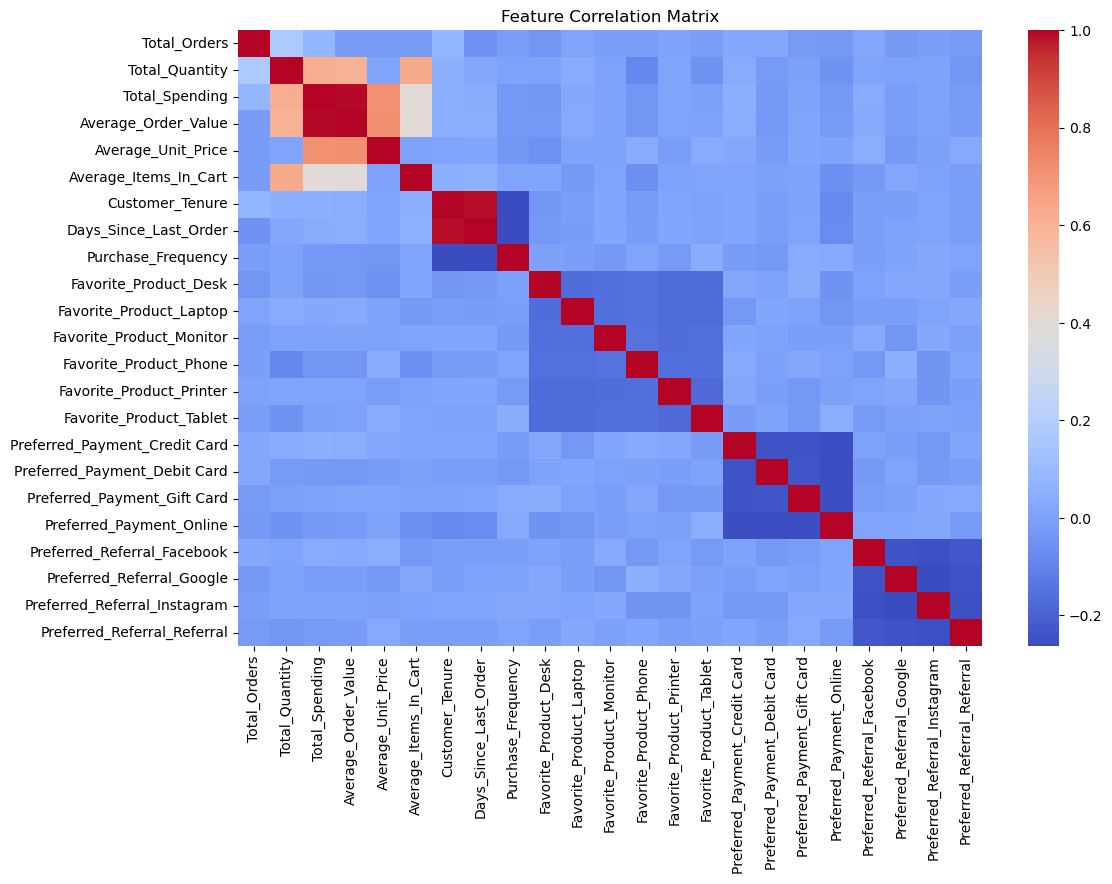

In [46]:
## Correlation Analysis

plt.figure(figsize=(12,8))

sns.heatmap(

    features.corr(),

    cmap="coolwarm",

    annot=False

)

plt.title("Feature Correlation Matrix")

plt.show()

In [47]:
## Final Feature Set

print("Customer Dataset Shape :", customer_df.shape)

print("Encoded Dataset Shape :", customer_encoded.shape)

print("Scaled Dataset Shape :", scaled_df.shape)

print("\nSelected Features")

display(features.columns.to_frame(name="Feature"))

Customer Dataset Shape : (1189, 15)
Encoded Dataset Shape : (1189, 26)
Scaled Dataset Shape : (1189, 23)

Selected Features


,Feature
Total_Orders,Total_Orders
Total_Quantity,Total_Quantity
Total_Spending,Total_Spending
Average_Order_Value,Average_Order_Value
Average_Unit_Price,Average_Unit_Price
Average_Items_In_Cart,Average_Items_In_Cart
Customer_Tenure,Customer_Tenure
Days_Since_Last_Order,Days_Since_Last_Order
Purchase_Frequency,Purchase_Frequency
Favorite_Product_Desk,Favorite_Product_Desk


In [50]:
## Feature Engineering Completed

print("FEATURE ENGINEERING COMPLETED")

print(f"Customers : {customer_df.shape[0]}")

print(f"Features : {features.shape[1]}")

print("Dataset Ready for PCA")

FEATURE ENGINEERING COMPLETED
Customers : 1189
Features : 23
Dataset Ready for PCA


### Principal Component Analysis (PCA)

In [53]:
## Apply PCA

pca = PCA(random_state=RANDOM_STATE)

pca_features = pca.fit_transform(scaled_df)

print("PCA Applied Successfully.")

PCA Applied Successfully.


In [54]:
## Explained Variance Ratio

explained_variance = pd.DataFrame({

    "Principal Component":[
        f"PC{i}" for i in range(
            1,
            len(pca.explained_variance_ratio_)+1
        )
    ],

    "Explained Variance":
    pca.explained_variance_ratio_,

    "Cumulative Variance":
    np.cumsum(
        pca.explained_variance_ratio_
    )

})

display(explained_variance)

,Principal Component,Explained Variance,Cumulative Variance
0,PC1,0.138655,0.138655
1,PC2,0.091849,0.230504
2,PC3,0.062801,0.293305
3,PC4,0.058219,0.351524
4,PC5,0.057548,0.409071
5,PC6,0.056385,0.465456
6,PC7,0.054952,0.520408
7,PC8,0.053088,0.573496
8,PC9,0.052435,0.625930
9,PC10,0.050717,0.676647


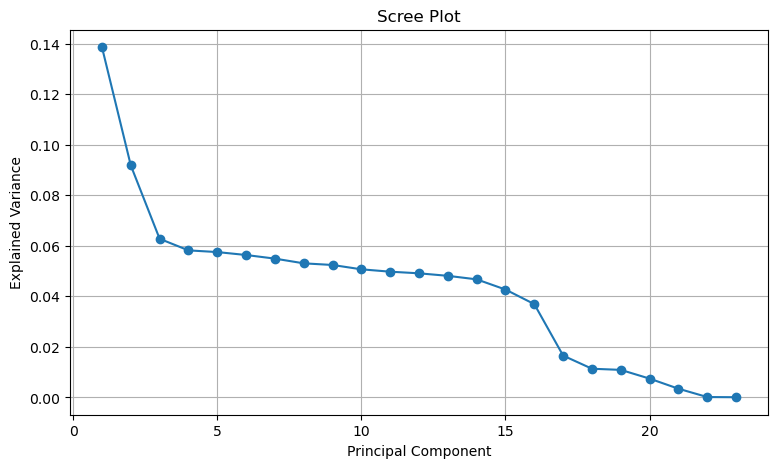

In [55]:
## Scree Plot
plt.figure(figsize=(9,5))

plt.plot(

    range(
        1,
        len(pca.explained_variance_ratio_)+1
    ),

    pca.explained_variance_ratio_,

    marker="o"

)

plt.xlabel("Principal Component")

plt.ylabel("Explained Variance")

plt.title("Scree Plot")

plt.grid(True)

plt.show()

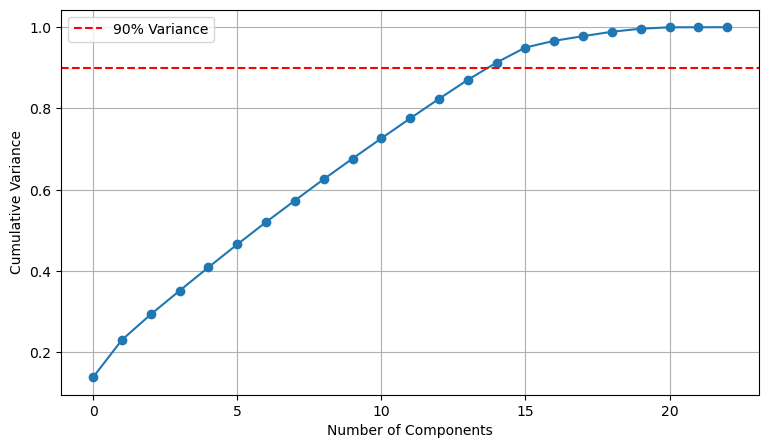

In [56]:
## Cumulative Explained Variance

plt.figure(figsize=(9,5))

plt.plot(

    np.cumsum(
        pca.explained_variance_ratio_
    ),

    marker="o"

)

plt.axhline(

    y=0.90,

    linestyle="--",

    color="red",

    label="90% Variance"

)

plt.legend()

plt.xlabel("Number of Components")

plt.ylabel("Cumulative Variance")

plt.grid(True)

plt.show()

In [57]:
## Select Optimal Components

optimal_components = np.argmax(

    np.cumsum(
        pca.explained_variance_ratio_
    ) >= 0.90

) + 1

print(
    f"Optimal Components : {optimal_components}"
)

Optimal Components : 15


In [58]:
## Build PCA Dataset

pca = PCA(

    n_components=optimal_components,

    random_state=RANDOM_STATE

)

principal_components = pca.fit_transform(
    scaled_df
)

pca_df = pd.DataFrame(

    principal_components,

    columns=[
        f"PC{i}"
        for i in range(
            1,
            optimal_components+1
        )
    ]

)

display(pca_df.head())

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15
0,0.802671,0.787762,1.025142,-1.182020,0.991695,-1.432738,0.021266,-1.185292,-1.193590,-0.249368,-1.427252,1.118745,-0.501637,-0.039443,-0.432643
1,-1.809448,-0.623129,-1.390950,1.816966,-0.027037,-0.203463,0.830543,0.493167,0.172894,-2.082961,-0.392088,-1.020856,0.081919,-0.330746,-0.915154
2,0.677863,1.101807,2.542259,0.392582,1.901808,-1.689297,-0.189819,-1.188358,-0.507528,0.452468,1.870320,0.122345,1.046733,-0.410319,0.355823
3,0.783607,-0.674492,-1.756819,0.828965,-1.544874,0.114668,-1.289666,-1.341679,-0.628700,1.009586,-0.501696,0.089276,0.854980,0.460485,0.501141
4,0.058640,-0.056278,-3.699272,-1.014481,0.121745,1.721396,0.712359,-1.159625,0.774151,1.218203,0.171921,0.091168,1.345727,0.595786,-0.019912


In [59]:
## PCA Feature Information

print("Original Features :", scaled_df.shape[1])

print("Reduced Features :", pca_df.shape[1])

print("Reduction :", scaled_df.shape[1]-pca_df.shape[1])

Original Features : 23
Reduced Features : 15
Reduction : 8


In [60]:
## Two-Dimensional PCA Projection

pca_visual = PCA(

    n_components=2,

    random_state=RANDOM_STATE

)

visual_data = pca_visual.fit_transform(
    scaled_df
)

visual_df = pd.DataFrame(

    visual_data,

    columns=["PC1","PC2"]

)

display(visual_df.head())

,PC1,PC2
0,0.802671,0.787762
1,-1.809448,-0.623129
2,0.677863,1.101807
3,0.783607,-0.674492
4,0.058640,-0.056278


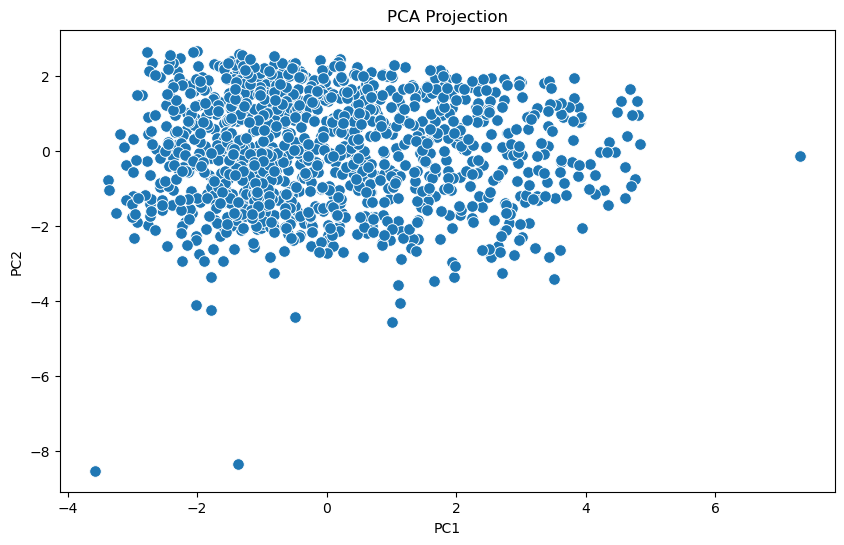

In [61]:
## PCA Scatter Plot

plt.figure(figsize=(10,6))

sns.scatterplot(

    data=visual_df,

    x="PC1",

    y="PC2",

    s=70

)

plt.title("PCA Projection")

plt.show()

In [62]:
## PCA Summary

summary = pd.DataFrame({

    "Metric":[

        "Original Features",

        "Selected Components",

        "Explained Variance"

    ],

    "Value":[

        scaled_df.shape[1],

        optimal_components,

        round(
            np.sum(
                pca.explained_variance_ratio_
            ),
            4
        )

    ]

})

display(summary)

,Metric,Value
0,Original Features,23.0000
1,Selected Components,15.0000
2,Explained Variance,0.9132


In [63]:
## PCA Completed

print("PCA COMPLETED SUCCESSFULLY")

print(f"Input Shape : {scaled_df.shape}")

print(f"PCA Shape : {pca_df.shape}")

print(f"Variance Retained : {np.sum(pca.explained_variance_ratio_):.2%}")

PCA COMPLETED SUCCESSFULLY
Input Shape : (1189, 23)
PCA Shape : (1189, 15)
Variance Retained : 91.32%


### K-Means Clustering

In [64]:
## Elbow Method

inertia = []

k_values = range(2, 11)

for k in k_values:

    model = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10
    )

    model.fit(pca_df)

    inertia.append(model.inertia_)

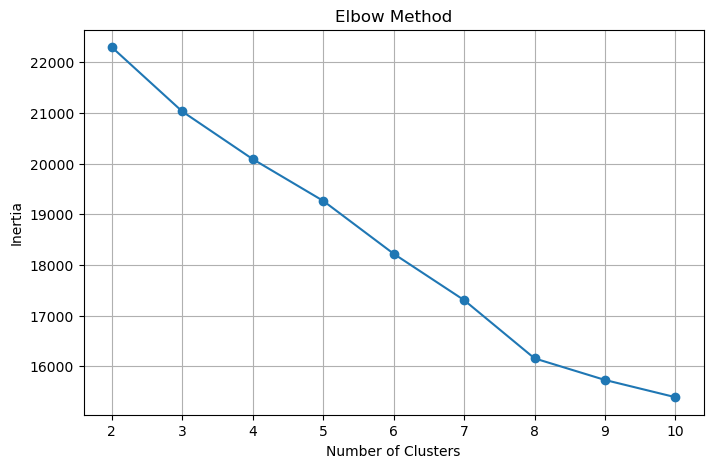

In [65]:
plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    inertia,
    marker="o"
)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.grid(True)

plt.show()

In [66]:
## Silhouette Score Analysis

silhouette_scores = []

for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10
    )

    labels = model.fit_predict(pca_df)

    silhouette_scores.append(
        silhouette_score(
            pca_df,
            labels
        )
    )

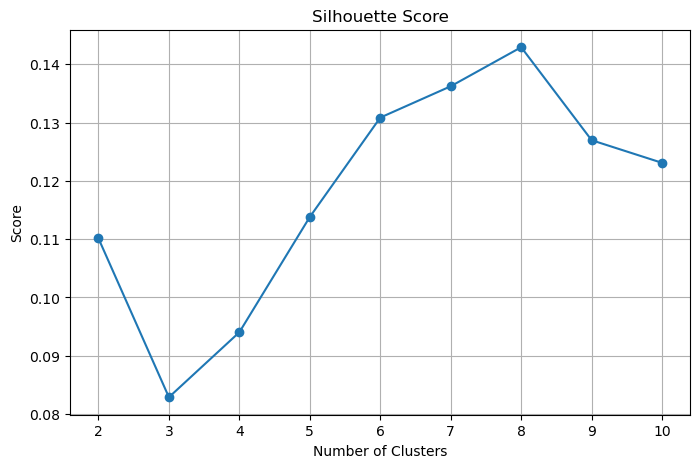

In [67]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    silhouette_scores,
    marker="o"
)

plt.title("Silhouette Score")

plt.xlabel("Number of Clusters")

plt.ylabel("Score")

plt.grid(True)

plt.show()

In [68]:
## Select Optimal K
optimal_k = np.argmax(silhouette_scores) + 2

print(f"Optimal Number of Clusters : {optimal_k}")

Optimal Number of Clusters : 8


In [69]:
## Train Final K-Means Model

kmeans = KMeans(

    n_clusters=optimal_k,

    random_state=RANDOM_STATE,

    n_init=10

)

customer_df["Cluster"] = kmeans.fit_predict(pca_df)

pca_df["Cluster"] = customer_df["Cluster"]

display(customer_df.head())

,CustomerID,Total_Orders,Total_Quantity,Total_Spending,Average_Order_Value,Average_Unit_Price,Average_Items_In_Cart,First_Purchase,Last_Purchase,Customer_Tenure,Days_Since_Last_Order,Purchase_Frequency,Favorite_Product,Preferred_Payment,Preferred_Referral,Cluster
0,C10002,1,3.0,1470.03,1470.03,490.01,4.0,2023-10-16,2023-10-16,623,623,0.0,Printer,Cash,Facebook,1
1,C10054,1,2.0,153.48,153.48,76.74,7.0,2024-10-14,2024-10-14,259,259,0.0,Laptop,Cash,Instagram,0
2,C10126,1,2.0,1349.80,1349.80,674.90,4.0,2023-06-18,2023-06-18,743,743,0.0,Monitor,Online,Facebook,6
3,C10154,1,4.0,1303.04,1303.04,325.76,8.0,2024-07-29,2024-07-29,336,336,0.0,Desk,Gift Card,Email,7
4,C10211,1,5.0,635.90,635.90,127.18,10.0,2024-05-09,2024-05-09,417,417,0.0,Desk,Debit Card,Google,7


In [70]:
## Cluster Distribution

cluster_count = customer_df["Cluster"].value_counts().sort_index()

display(cluster_count)

Cluster
0    145
1    252
2    135
3    148
4     11
5    204
6    140
7    154
Name: count, dtype: int64

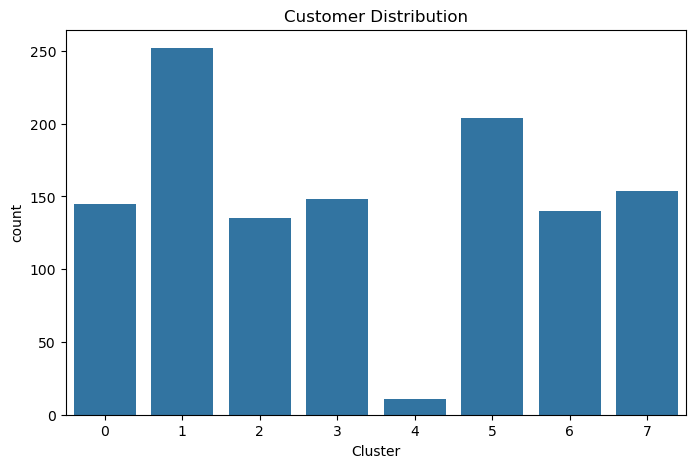

In [71]:
plt.figure(figsize=(8,5))

sns.countplot(

    data=customer_df,

    x="Cluster"

)

plt.title("Customer Distribution")

plt.show()

In [72]:
## Cluster Centers

centers = pd.DataFrame(

    kmeans.cluster_centers_,

    columns=pca_df.columns[:-1]

)

display(centers)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15
0,-0.415466,-0.123412,-0.107894,0.366732,-0.490681,0.032980,1.181007,0.010473,-0.550206,-1.438800,-0.228882,-1.308038,0.548254,-0.645755,-0.410892
1,-0.802154,0.168119,-0.164797,-0.458492,0.382503,-0.155936,-0.101954,0.145536,-0.538148,-0.339090,-0.560890,0.879989,-0.157531,-0.067357,-0.158195
2,-0.780801,-0.120368,0.805255,-0.725370,-0.777825,0.711442,-0.520927,-0.144002,0.448534,-0.476360,0.995992,-0.182800,-0.896679,1.533526,-0.555017
3,-0.609205,-0.116507,0.469060,0.580360,0.683598,0.691863,0.074093,0.782864,0.052230,1.538772,-0.619199,-0.739618,-0.918994,-0.537059,0.026772
4,1.451739,0.297315,-2.177750,-0.947735,1.169457,-1.861237,1.775606,0.606622,-0.588320,-1.973666,0.067792,-1.746523,-3.689897,2.437084,8.268232
5,2.815083,-0.111423,0.239681,0.005400,0.053711,0.081787,-0.063099,-0.029258,0.034415,-0.032848,-0.143118,0.154783,0.009570,-0.016576,-0.171034
6,-0.359896,0.260255,0.066540,0.411600,0.303823,-1.102712,0.063769,0.004764,0.366256,0.287861,1.978325,0.719454,0.271664,-0.987689,0.265891
7,-0.531850,-0.051652,-1.007872,0.169448,-0.569899,-0.037388,-0.660919,-0.883043,0.618741,0.771155,-0.758445,-0.071675,1.414723,0.635827,0.500813


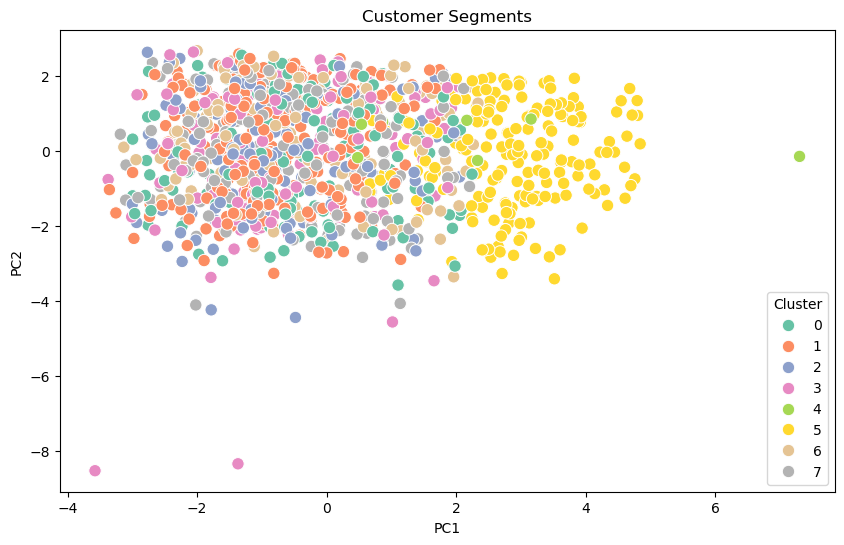

In [73]:
## Customer Segments Visualization

plt.figure(figsize=(10,6))

sns.scatterplot(

    data=pca_df,

    x="PC1",

    y="PC2",

    hue="Cluster",

    palette="Set2",

    s=80

)

plt.title("Customer Segments")

plt.show()

In [74]:
## Cluster Profile

cluster_profile = customer_df.groupby("Cluster").agg({

    "Total_Orders":"mean",

    "Total_Quantity":"mean",

    "Total_Spending":"mean",

    "Average_Order_Value":"mean",

    "Purchase_Frequency":"mean",

    "Customer_Tenure":"mean",

    "Days_Since_Last_Order":"mean"

}).round(2)

display(cluster_profile)

,Total_Orders,Total_Quantity,Total_Spending,Average_Order_Value,Purchase_Frequency,Customer_Tenure,Days_Since_Last_Order
Cluster,,,,,,,
0,1.0,2.81,847.97,847.97,0.01,434.79,434.79
1,1.0,2.67,651.64,651.64,0.01,461.89,461.89
2,1.0,2.41,773.56,773.56,0.01,438.94,438.94
3,1.0,2.50,784.56,784.56,0.02,450.50,450.50
4,2.0,5.45,1770.48,885.24,0.00,681.45,311.45
5,1.0,4.32,2403.56,2403.56,0.00,513.98,513.98
6,1.0,2.72,862.84,862.84,0.00,479.76,479.76
7,1.0,2.84,818.56,818.56,0.01,447.01,447.01


In [75]:
## Cluster Summary

summary = pd.DataFrame({

    "Metric":[

        "Optimal Clusters",

        "Total Customers",

        "Silhouette Score"

    ],

    "Value":[

        optimal_k,

        customer_df.shape[0],

        round(max(silhouette_scores),4)

    ]

})

display(summary)

,Metric,Value
0,Optimal Clusters,8.0000
1,Total Customers,1189.0000
2,Silhouette Score,0.1429


In [76]:
print("K-MEANS CLUSTERING COMPLETED")

print(f"Optimal Clusters : {optimal_k}")

print(f"Customers : {customer_df.shape[0]}")

print(f"Silhouette Score : {max(silhouette_scores):.4f}")

K-MEANS CLUSTERING COMPLETED
Optimal Clusters : 8
Customers : 1189
Silhouette Score : 0.1429


### Cluster Evaluation

In [77]:
## Clustering Evaluation Metrics

silhouette = silhouette_score(
    pca_df.drop(columns="Cluster"),
    customer_df["Cluster"]
)

davies = davies_bouldin_score(
    pca_df.drop(columns="Cluster"),
    customer_df["Cluster"]
)

calinski = calinski_harabasz_score(
    pca_df.drop(columns="Cluster"),
    customer_df["Cluster"]
)

evaluation = pd.DataFrame({

    "Metric":[

        "Silhouette Score",

        "Davies-Bouldin Index",

        "Calinski-Harabasz Score"

    ],

    "Value":[

        round(silhouette,4),

        round(davies,4),

        round(calinski,2)

    ]

})

display(evaluation)

,Metric,Value
0,Silhouette Score,0.1429
1,Davies-Bouldin Index,1.9898
2,Calinski-Harabasz Score,92.0800


In [78]:
## Cluster Characteristics

cluster_characteristics = customer_df.groupby("Cluster").agg({

    "Total_Orders":"mean",

    "Total_Quantity":"mean",

    "Total_Spending":"mean",

    "Average_Order_Value":"mean",

    "Customer_Tenure":"mean",

    "Days_Since_Last_Order":"mean"

}).round(2)

display(cluster_characteristics)

,Total_Orders,Total_Quantity,Total_Spending,Average_Order_Value,Customer_Tenure,Days_Since_Last_Order
Cluster,,,,,,
0,1.0,2.81,847.97,847.97,434.79,434.79
1,1.0,2.67,651.64,651.64,461.89,461.89
2,1.0,2.41,773.56,773.56,438.94,438.94
3,1.0,2.50,784.56,784.56,450.50,450.50
4,2.0,5.45,1770.48,885.24,681.45,311.45
5,1.0,4.32,2403.56,2403.56,513.98,513.98
6,1.0,2.72,862.84,862.84,479.76,479.76
7,1.0,2.84,818.56,818.56,447.01,447.01


In [79]:
## Highest Value Customer Segment

best_cluster = cluster_characteristics["Total_Spending"].idxmax()

highest_value = cluster_characteristics.loc[
    best_cluster,
    "Total_Spending"
]

print(f"Highest Value Cluster : {best_cluster}")

print(f"Average Spending : {highest_value:.2f}")

Highest Value Cluster : 5
Average Spending : 2403.56


Cluster
0    145
1    252
2    135
3    148
4     11
5    204
6    140
7    154
Name: count, dtype: int64

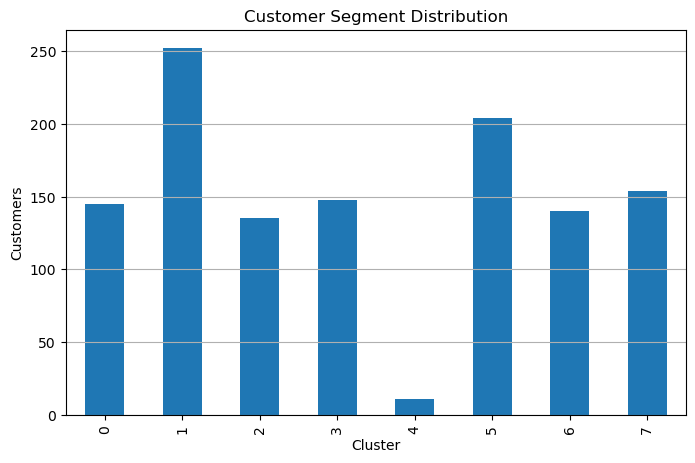

In [80]:
## Customer Segment Distribution

segment_distribution = customer_df["Cluster"].value_counts().sort_index()

display(segment_distribution)

plt.figure(figsize=(8,5))

segment_distribution.plot(
    kind="bar"
)

plt.title("Customer Segment Distribution")

plt.xlabel("Cluster")

plt.ylabel("Customers")

plt.grid(axis="y")

plt.show()

In [82]:
cluster_summary = customer_df.groupby("Cluster")["Total_Spending"].mean()

recommendations = []

for cluster in cluster_summary.index:

    spending = cluster_summary.loc[cluster]

    if spending >= cluster_summary.quantile(0.75):

        rec = "Offer VIP rewards and premium membership."

    elif spending >= cluster_summary.median():

        rec = "Recommend cross-selling and loyalty points."

    else:

        rec = "Provide discounts and promotional offers."

    recommendations.append(rec)

recommendation_df = pd.DataFrame({

    "Cluster": cluster_summary.index,

    "Recommendation": recommendations

})

display(recommendation_df)

,Cluster,Recommendation
0,0,Recommend cross-selling and loyalty points.
1,1,Provide discounts and promotional offers.
2,2,Provide discounts and promotional offers.
3,3,Provide discounts and promotional offers.
4,4,Offer VIP rewards and premium membership.
5,5,Offer VIP rewards and premium membership.
6,6,Recommend cross-selling and loyalty points.
7,7,Provide discounts and promotional offers.


In [83]:
## Export Results

customer_df.to_csv(
    "Customer_Segmentation_Output.csv",
    index=False
)

customer_df.to_excel(
    "Customer_Segmentation_Output.xlsx",
    index=False
)

print("Results exported successfully.")

Results exported successfully.


In [84]:
## Save Trained Model

joblib.dump(

    scaler,

    "scaler.pkl"

)

joblib.dump(

    kmeans,

    "kmeans_model.pkl"

)

print("Model saved successfully.")

Model saved successfully.


In [85]:
## Project Summary

summary = pd.DataFrame({

    "Project Stage":[

        "Data Cleaning",

        "Exploratory Data Analysis",

        "Feature Engineering",

        "Feature Scaling",

        "Principal Component Analysis",

        "K-Means Clustering",

        "Model Evaluation",

        "Export Results"

    ],

    "Status":[

        "Completed",

        "Completed",

        "Completed",

        "Completed",

        "Completed",

        "Completed",

        "Completed",

        "Completed"

    ]

})

display(summary)

,Project Stage,Status
0,Data Cleaning,Completed
1,Exploratory Data Analysis,Completed
2,Feature Engineering,Completed
3,Feature Scaling,Completed
4,Principal Component Analysis,Completed
5,K-Means Clustering,Completed
6,Model Evaluation,Completed
7,Export Results,Completed


In [86]:
# Conclusion
print("CUSTOMER SEGMENTATION PROJECT COMPLETED")

print(f"Total Customers : {customer_df.shape[0]}")

print(f"Optimal Clusters : {optimal_k}")

print(f"Silhouette Score : {silhouette:.4f}")

print(f"Davies-Bouldin Index : {davies:.4f}")

print(f"Calinski-Harabasz Score : {calinski:.2f}")

print("\nGenerated Files:")

print("✓ Customer_Segmentation_Output.csv")

print("✓ Customer_Segmentation_Output.xlsx")

print("✓ scaler.pkl")

print("✓ kmeans_model.pkl")

print("\nProject Executed Successfully.")

CUSTOMER SEGMENTATION PROJECT COMPLETED
Total Customers : 1189
Optimal Clusters : 8
Silhouette Score : 0.1429
Davies-Bouldin Index : 1.9898
Calinski-Harabasz Score : 92.08

Generated Files:
✓ Customer_Segmentation_Output.csv
✓ Customer_Segmentation_Output.xlsx
✓ scaler.pkl
✓ kmeans_model.pkl

Project Executed Successfully.
